# Convergence — quels leviers RLlib sont *purs* ?

Lit les `logs/sweep_*.jsonl` et classe chaque levier en trois catégories :

| Catégorie | Signature dans les données |
|---|---|
| **pur** | courbe retour-vs-**échantillons** superposée à la baseline, temps mural différent |
| **compromis gagnant** | efficacité-échantillon dégradée, mais seuil atteint plus vite **en temps** |
| **compromis perdant** | dégradée, et le gain de débit ne compense pas |

Rappel de lecture (important) : la moitié « retour vs échantillons » ne dépend
**pas** du hardware (c'est de l'arithmétique de gradient) — ces conclusions
valent pour n'importe quelle machine. La moitié « temps mural » dépend, elle,
entièrement de la machine : à relire sur l'A40.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# np.trapezoid n'existe qu'en numpy>=2 ; numpy 1.x (jetson, JetPack)
# n'a que np.trapz. Le notebook doit tourner sur les deux.
_trapz = getattr(np, "trapezoid", None) or np.trapz
import pandas as pd

LOGS_DIR = Path("../logs")

# Seuil de retour à atteindre. Pendulum 2 agents : `episode_return_mean` est
# SOMMÉ sur les agents -> aléatoire ~ -2400, plateau ~ -320.
# VALIDÉ sur le run pilote (S2, 300k pas, Jetson CPU) : la baseline franchit
# -800 vers ~110k pas, soit en pleine partie raide de la courbe (donc
# discriminant) et à 1/3 du budget (les configs lentes ont de la marge
# avant d'être censurées).
THRESHOLD = -800.0

rows = []
for f in sorted(LOGS_DIR.glob("sweep_*.jsonl")):
    with open(f) as fh:
        for line in fh:
            if line.strip():
                rows.append(json.loads(line))

if not rows:
    print("Aucun log de sweep. Lance d'abord :\n"
          "  python -m bench.run_sweep --configs S1,S2,S3,S4,S5,S6,S7,S8 "
          "--seeds 0,1,2 --max-env-steps 300000")
    df = pd.DataFrame()
else:
    df = pd.DataFrame(rows).rename(columns={
        "env_runners/episode_return_mean": "return_mean",
        "bench_config/name": "config",
        "bench_config/lever": "lever",
        "bench_config/hypothesis": "hypothesis",
    })
    print(f"{len(df)} itérations | configs: {sorted(df['config'].unique())} "
          f"| graines: {sorted(df['seed'].unique())}")
    display(df.groupby(["config", "lever"])["env_steps_sampled"].max().to_frame("pas atteints"))

926 itérations | configs: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7'] | graines: [np.int64(0), np.int64(1)]


,,pas atteints
config,lever,
S1,batch=1024,300032
S2,baseline,303104
S3,batch=16384,311296
S4,batch=65536,0
S5,minibatch=128,303104
S6,minibatch=4096,303104
S7,num_env_runners=1,303104


## 1. Retour vs échantillons — le test de pureté (indépendant du hardware)

Deux configs dont les courbes se superposent ici font **les mêmes maths** :
le levier qui les sépare est pur, et on peut choisir la plus rapide au chrono
sans rien perdre.

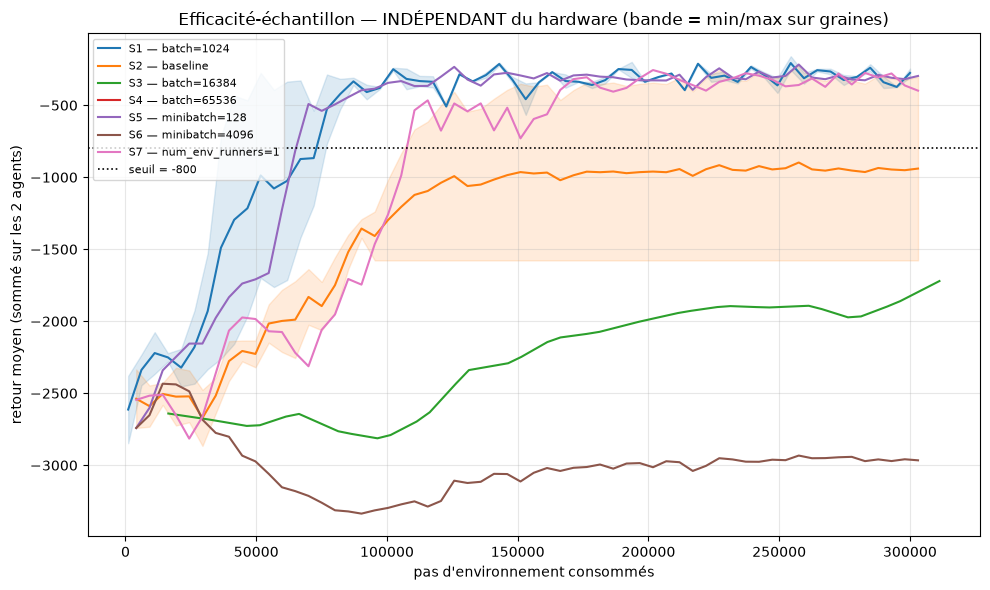

In [2]:
def curves(ax, x_col, xlabel, title):
    """Une courbe par config, moyenne sur les graines + bande min/max."""
    for config, g in df.groupby("config"):
        # Grille commune : les graines n'ont pas exactement les mêmes abscisses.
        grid = np.linspace(g[x_col].min(), g[x_col].max(), 60)
        per_seed = []
        for _, gs in g.groupby("seed"):
            gs = gs.sort_values(x_col)
            per_seed.append(np.interp(grid, gs[x_col], gs["return_mean"]))
        arr = np.vstack(per_seed)
        lever = g["lever"].iloc[0]
        line, = ax.plot(grid, arr.mean(axis=0), label=f"{config} — {lever}")
        if arr.shape[0] > 1:
            ax.fill_between(grid, arr.min(axis=0), arr.max(axis=0),
                            alpha=0.15, color=line.get_color())
    ax.axhline(THRESHOLD, color="black", linestyle=":", linewidth=1.2,
               label=f"seuil = {THRESHOLD:g}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("retour moyen (sommé sur les 2 agents)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    curves(ax, "env_steps_sampled", "pas d'environnement consommés",
           "Efficacité-échantillon — INDÉPENDANT du hardware (bande = min/max sur graines)")
    fig.tight_layout()
    plt.show()

## 2. Retour vs temps mural — le résultat final (dépend de la machine)

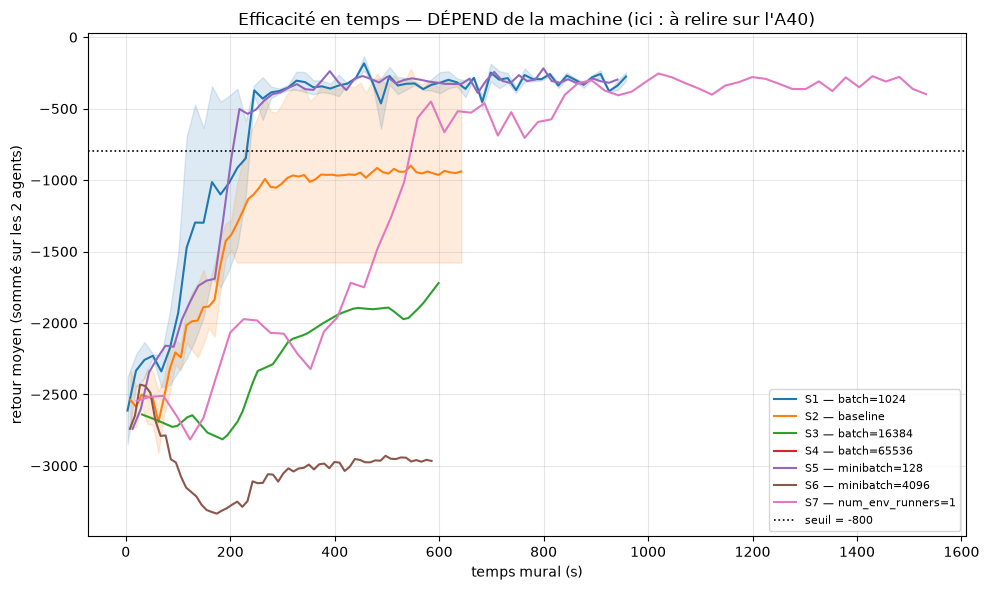

In [3]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    curves(ax, "cumulative_time_s", "temps mural (s)",
           "Efficacité en temps — DÉPEND de la machine (ici : à relire sur l'A40)")
    fig.tight_layout()
    plt.show()

## 3. Seuils atteints — et classement des leviers

Un run qui n'atteint jamais le seuil est **censuré** (`> budget`), jamais
supprimé : le jeter biaiserait le classement en faveur des configs qui échouent.

In [4]:
def first_crossing(g, x_col):
    """Abscisse du 1er franchissement du seuil ; NaN = censuré (jamais atteint)."""
    hit = g[g["return_mean"] >= THRESHOLD]
    return hit[x_col].iloc[0] if len(hit) else np.nan

if not df.empty:
    recs = []
    for (config, seed), g in df.groupby(["config", "seed"]):
        g = g.sort_values("env_steps_sampled")
        recs.append({
            "config": config,
            "lever": g["lever"].iloc[0],
            "seed": seed,
            "samples_to_threshold": first_crossing(g, "env_steps_sampled"),
            "time_to_threshold_s": first_crossing(g, "cumulative_time_s"),
            "final_return": g["return_mean"].iloc[-1],
            # AUC du retour vs échantillons, normalisée par le budget.
            # BEAUCOUP moins bruitée que le premier franchissement de seuil :
            # mesuré 2,3x d'écart entre deux graines de S1 sur le crossing,
            # alors que l'AUC intègre toute la courbe. Métrique PRIMAIRE
            # pour classer les configs ; le crossing reste affiché mais ne
            # supporte pas de conclusion fine à 3 graines.
            "auc_return": _trapz(g["return_mean"], g["env_steps_sampled"])
                          / max(g["env_steps_sampled"].max(), 1),
            "throughput_sps": g["env_steps_sampled"].max() / g["cumulative_time_s"].max(),
        })
    per_run = pd.DataFrame(recs)

    summary = per_run.groupby(["config", "lever"]).agg(
        samples_to_thr=("samples_to_threshold", "mean"),
        time_to_thr_s=("time_to_threshold_s", "mean"),
        n_censored=("samples_to_threshold", lambda s: int(s.isna().sum())),
        final_return=("final_return", "mean"),
        auc=("auc_return", "mean"),
        auc_std=("auc_return", "std"),
        throughput=("throughput_sps", "mean"),
    ).reset_index()

    # Comparaison relative à la baseline S2 (>1 = moins bon que la baseline).
    base = summary[summary["config"] == "S2"]
    if len(base):
        b = base.iloc[0]
        summary["samples_vs_base"] = summary["samples_to_thr"] / b["samples_to_thr"]
        summary["time_vs_base"] = summary["time_to_thr_s"] / b["time_to_thr_s"]

        def verdict(r):
            if r["n_censored"] > 0 and np.isnan(r["samples_to_thr"]):
                return "jamais convergé"
            if abs(r["samples_vs_base"] - 1) < 0.15:
                return "PUR" if r["time_vs_base"] < 0.95 else "pur, sans gain"
            return "compromis gagnant" if r["time_vs_base"] < 1 else "compromis perdant"

        summary["verdict"] = summary.apply(verdict, axis=1)

    display(summary.round(3))

,config,lever,samples_to_thr,time_to_thr_s,n_censored,final_return,auc,auc_std,throughput,samples_vs_base,time_vs_base,verdict
0,S1,batch=1024,55808.0,177.267,0,-275.531,-649.862,166.879,316.259,0.524,0.780,compromis gagnant
1,S2,baseline,106496.0,227.349,1,-939.748,-1526.384,910.913,463.650,1.000,1.000,"pur, sans gain"
2,S3,batch=16384,NaN,NaN,1,-1720.800,-2147.498,NaN,519.827,NaN,NaN,jamais convergé
3,S4,batch=65536,NaN,NaN,1,NaN,NaN,NaN,0.000,NaN,NaN,jamais convergé
4,S5,minibatch=128,65536.0,205.582,0,-296.684,-652.820,NaN,322.010,0.615,0.904,compromis gagnant
5,S6,minibatch=4096,NaN,NaN,1,-2965.741,-2969.338,NaN,517.725,NaN,NaN,jamais convergé
6,S7,num_env_runners=1,110592.0,560.658,0,-398.615,-970.497,NaN,197.833,1.038,2.466,"pur, sans gain"


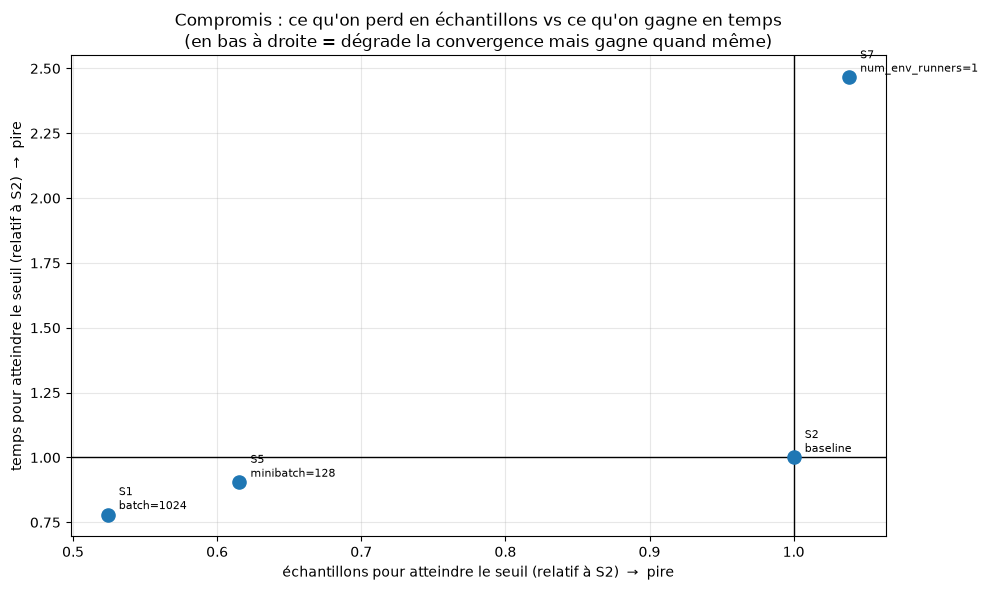

In [5]:
if not df.empty and "samples_vs_base" in summary:
    fig, ax = plt.subplots(figsize=(10, 6))
    ok = summary.dropna(subset=["samples_vs_base", "time_vs_base"])
    ax.scatter(ok["samples_vs_base"], ok["time_vs_base"], s=90, zorder=3)
    for _, r in ok.iterrows():
        ax.annotate(f"{r['config']}\n{r['lever']}",
                    (r["samples_vs_base"], r["time_vs_base"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)
    ax.axhline(1, color="black", linewidth=1)
    ax.axvline(1, color="black", linewidth=1)
    ax.set_xlabel("échantillons pour atteindre le seuil (relatif à S2)  →  pire")
    ax.set_ylabel("temps pour atteindre le seuil (relatif à S2)  →  pire")
    ax.set_title("Compromis : ce qu'on perd en échantillons vs ce qu'on gagne en temps\n"
                 "(en bas à droite = dégrade la convergence mais gagne quand même)")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

## 4. Contrôle : bruit du gradient à nombre d'updates égal

S1 (batch 1024, mb 128) et S5 (batch 4096, mb 128) font le **même nombre de
gradient steps par échantillon** (46.9 pour 1000 pas) avec des tailles de batch
4× différentes. Leur écart isole donc l'effet du **bruit du gradient** seul,
débarrassé de l'effet « moins d'updates » qui domine partout ailleurs.

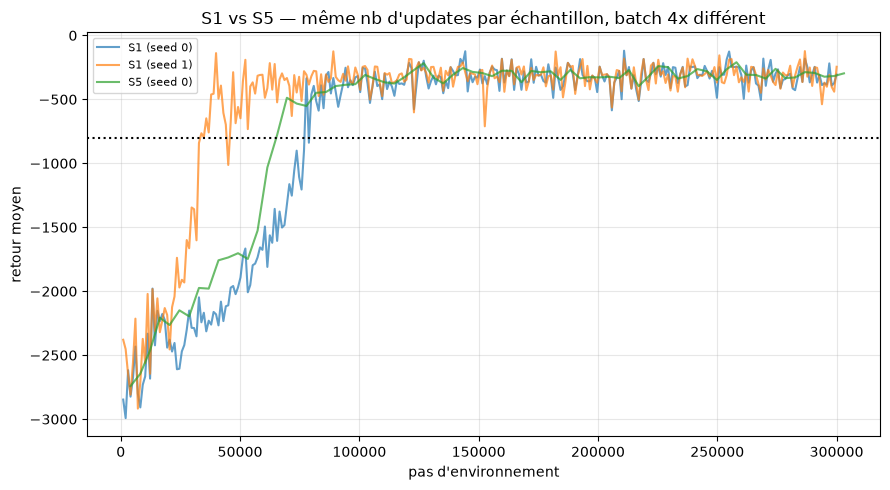

In [6]:
if not df.empty:
    pair = df[df["config"].isin(["S1", "S5"])]
    if pair["config"].nunique() == 2:
        fig, ax = plt.subplots(figsize=(9, 5))
        for config, g in pair.groupby("config"):
            for seed, gs in g.groupby("seed"):
                gs = gs.sort_values("env_steps_sampled")
                ax.plot(gs["env_steps_sampled"], gs["return_mean"], alpha=0.7,
                        label=f"{config} (seed {seed})")
        ax.axhline(THRESHOLD, color="black", linestyle=":")
        ax.set_xlabel("pas d'environnement")
        ax.set_ylabel("retour moyen")
        ax.set_title("S1 vs S5 — même nb d'updates par échantillon, batch 4x différent")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()
    else:
        print("S1 et S5 pas tous les deux présents dans les logs — contrôle non calculable.")